In [1]:
# Data Manipulation Libraries
import numpy as np
import pandas as pd

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Import Logging Libraties
import logging

logging.basicConfig(level=logging.INFO,
                    filename='model.log',
                    filemode='w',
                    format='%(asctime)s - %(message)s - %(levelname)s',
                    force=True
    
)

# Filter Warnings
import warnings
warnings.filterwarnings('ignore')



In [2]:
# Step to be followed 
''' 
Step[1] :  Data Ingestion : Loading Data using pandas function
Step[2] :  Understand Dataset : Categorical and Numerical Column Information
Step[3] :  Descriptive Stats for Categorical and Numerical Columns
Step[4] :  Build stratergies based on type and nature of dataset and accordingly do preprocessing
'''

' \nStep[1] :  Data Ingestion : Loading Data using pandas function\nStep[2] :  Understand Dataset : Categorical and Numerical Column Information\nStep[3] :  Descriptive Stats for Categorical and Numerical Columns\nStep[4] :  Build stratergies based on type and nature of dataset and accordingly do preprocessing\n'

In [3]:
df = pd.read_csv(r'C:\telecom_churnmodel\data\churn.csv')


In [4]:
# Step2 : Checking Dataset Informaton
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

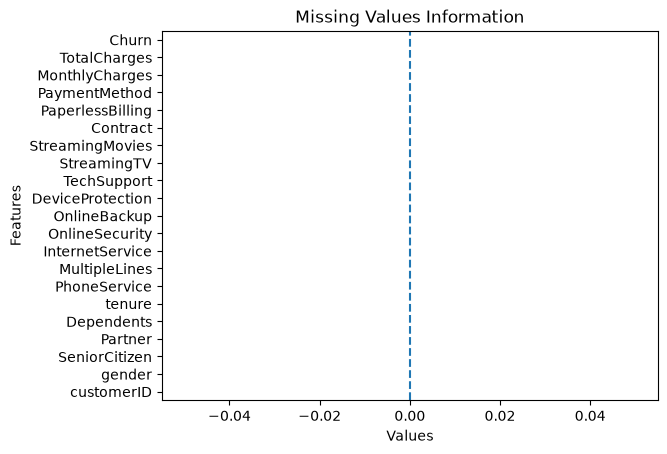

In [6]:
# Checking Missing Values Information using Graph

df.isnull().sum().plot(kind = 'barh')
plt.axvline(0,linestyle = '--')
plt.title('Missing Values Information')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

In [7]:
# Checking Duplicated values and drop the same

df.drop_duplicates()

'''No Duplicate Values found in database'''



'No Duplicate Values found in database'

In [8]:
# Checking Discriptive stats

numerical_data = df.select_dtypes(exclude = 'object')
categorical_data = df.select_dtypes(include = 'object')

In [9]:
# Encoding Target Column 
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,1


In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

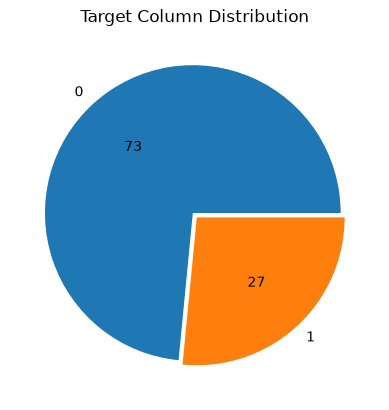

In [11]:
df['Churn'].value_counts().plot(kind = 'pie',
                                autopct = '%0.0f',
                                explode = [0.02,0.02])

plt.title("Target Column Distribution")
plt.show()

In [12]:
# Using Encoding Technice

le = LabelEncoder()
for i in categorical_data.columns:
    df[i] = le.fit_transform(df[i])

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4853,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1597,0
7039,1525,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,5698,0
7040,3367,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,2994,0
7041,5934,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,2660,1


In [13]:
# Droping Unwanted Columns 

df.drop(columns = 'customerID',inplace = True)

In [14]:
df.shape

(7043, 20)

In [15]:
# Data Preprocessing

'''
1.Nature of Machine Learnig Problem : Classification Model
2.Target Column : Categorical Nature (Yes : 1,No: 0)
3.befour Building Machine Learing model ensure data set must be Balance
4.Ensure Data Leakage not happen during execution of model :
    - If data leackage found hen model become overfit
5.Metrix for classification models are as follows :
    - confusion Matrix (TP,TN,FP.FN)
    - accuracy,precision,recall,f1-score
    - roc and auc curve
    
=====================================================================================
# concept of Preventing Data Leackage :
    - split the Data into Input Features and Target column i.e. X and y
    - split the Data set into traim and test i.e. seen Data and Unseen Data
    - Now use over sampling technices in order to balance target column 
    - building Machine Learning
'''


'\n1.Nature of Machine Learnig Problem : Classification Model\n2.Target Column : Categorical Nature (Yes : 1,No: 0)\n3.befour Building Machine Learing model ensure data set must be Balance\n4.Ensure Data Leakage not happen during execution of model :\n    - If data leackage found hen model become overfit\n5.Metrix for classification models are as follows :\n    - confusion Matrix (TP,TN,FP.FN)\n    - accuracy,precision,recall,f1-score\n    - roc and auc curve\n\n=====================================================================================\n# concept of Preventing Data Leackage :\n    - split the Data into Input Features and Target column i.e. X and y\n    - split the Data set into traim and test i.e. seen Data and Unseen Data\n    - Now use over sampling technices in order to balance target column \n    - building Machine Learning\n'

In [16]:
# Split the dataset into input fetures and target column i.e. X and y

X = df.drop(columns = 'Churn')
y = df['Churn']

# split the Data set into traim and test i.e. seen Data and Unseen Data

X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size = 0.3,
                                                 random_state = 1)


from imblearn.over_sampling import SMOTE
sm = SMOTE()

X_train,y_train = sm.fit_resample(X_train,y_train)


In [17]:
y_train.value_counts()

Churn
0    3589
1    3589
Name: count, dtype: int64

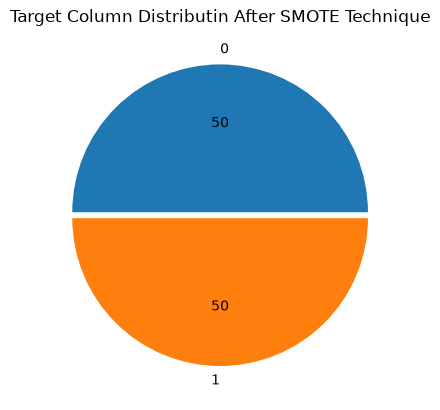

In [18]:
y_train.value_counts().plot(kind = 'pie',
                            autopct = '%0.0f',
                            explode = [0.02,0.02])
plt.title('Target Column Distributin After SMOTE Technique')
plt.show()

In [19]:
# Building Logical Regrassion Model

from sklearn.linear_model import LogisticRegression
LR = LogisticRegression().fit(X_train,y_train)
y_pred = LR.predict(X_test)

accuracyscore = accuracy_score(y_test,y_pred)
accuracyscore

0.7718883104590629

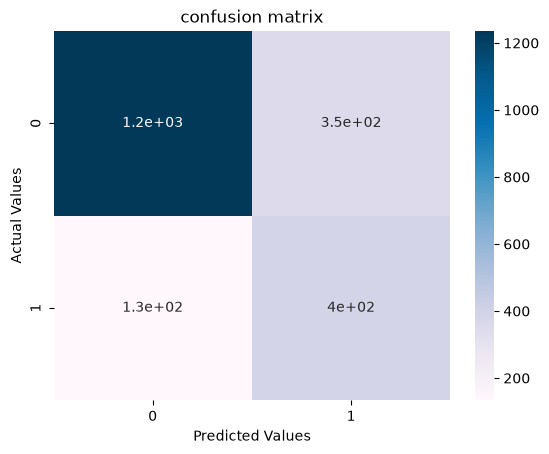

In [20]:
cf = confusion_matrix(y_test,y_pred)
sns.heatmap(cf,annot = True,cmap = 'PuBu')
plt.title('confusion matrix')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

In [21]:
classificationreport = classification_report(y_test,y_pred)
print(classificationreport)

              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1585
           1       0.53      0.75      0.62       528

    accuracy                           0.77      2113
   macro avg       0.72      0.76      0.73      2113
weighted avg       0.81      0.77      0.78      2113



In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
DT= DecisionTreeClassifier().fit(X_train,y_train)
y_pred = DT.predict(X_test)
classificationreport_DT = classification_report(y_test,y_pred)
print(classificationreport_DT)
accuracyscore = accuracy_score(y_test,y_pred)
accuracyscore


              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1585
           1       0.45      0.55      0.50       528

    accuracy                           0.72      2113
   macro avg       0.65      0.66      0.65      2113
weighted avg       0.74      0.72      0.73      2113



0.7221959299574066

In [23]:
RF= RandomForestClassifier().fit(X_train,y_train)
y_pred = RF.predict(X_test)
classificationreport_RF = classification_report(y_test,y_pred)
print(classificationreport_RF)
accuracyscore = accuracy_score(y_test,y_pred)
accuracyscore


              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1585
           1       0.58      0.63      0.60       528

    accuracy                           0.79      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.80      0.79      0.79      2113



0.791292001893043

In [24]:
sm = SMOTE(random_state=42).fit(X_train,y_train)
X_train, y_train = sm.fit_resample(X_train, y_train)

print('Resampled dataset shape %s' ,(y_train))

classificationreport_sm= classification_report(y_test,y_pred)
print(classificationreport_sm)

Resampled dataset shape %s 0       0
1       1
2       1
3       1
4       0
       ..
7173    1
7174    1
7175    1
7176    1
7177    1
Name: Churn, Length: 7178, dtype: int64
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1585
           1       0.58      0.63      0.60       528

    accuracy                           0.79      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.80      0.79      0.79      2113



In [ ]:
# KNeighborsClassifier KNN

from sklearn.neighbors import KNeighborsClassifier 
model_KNN = KNeighborsClassifier(n_neighbors=5).fit(X_train,y_train)
y_pred = model_KNN.predict(X_test)
classificationreport_KNN = classification_report(y_test,y_pred)
print(classificationreport_RF)
accuracyscore = accuracy_score(y_test,y_pred)
accuracyscore

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1585
           1       0.58      0.63      0.60       528

    accuracy                           0.79      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.80      0.79      0.79      2113



0.6952200662565073

In [26]:
from sklearn.svm import SVC

In [ ]:
# Support Vector Machines SVM

model_SVM = SVC().fit(X_train,y_train)
y_pred = model_SVM.predict(X_test)
classificationreport = classification_report(y_test,y_pred)
print(classificationreport)
accuracyscore = accuracy_score(y_test,y_pred)
accuracyscore

              precision    recall  f1-score   support

           0       0.82      0.55      0.66      1585
           1       0.32      0.64      0.43       528

    accuracy                           0.58      2113
   macro avg       0.57      0.60      0.55      2113
weighted avg       0.70      0.58      0.60      2113



0.575011831519167

In [ ]:
F1 Score is = it is tread of between pression and accurac